# Sousse Mobility Study — Notebook 02


- Dataset: 230 survey responses, KK → Beb Bhar corridor


Author: Mariem Belaid | Sousse, Tunisia

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import xgboost as xgb

print("All libraries loaded ✓")


All libraries loaded ✓


In [4]:

df = pd.read_csv('Mobility_survey2.csv')
df.head()
print(df.shape)
print(df.columns.tolist())


(230, 12)
['Timestamp', 'station', 'distination', 'frequency', 'time_slot', 'wait_time', 'case    ', 'worst_day', 'use_bus', 'why_taxi_over_bus', 'worst_time_place', 'solution']


In [5]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Timestamp', 'station', 'distination', 'frequency', 'time_slot', 'wait_time', 'case', 'worst_day', 'use_bus', 'why_taxi_over_bus', 'worst_time_place', 'solution']


In [6]:
print(df.isnull().sum())

Timestamp             0
station               0
distination           0
frequency             0
time_slot             0
wait_time             0
case                  0
worst_day             0
use_bus               0
why_taxi_over_bus    58
worst_time_place     58
solution             79
dtype: int64


In [7]:
df['case_full']      = df['case'].str.contains('ممتلئ', na=False).astype(int)
df['case_wrongline'] = df['case'].str.contains('سهلول', na=False).astype(int)
df['case_nogap']     = df['case'].str.contains('لا يمر', na=False).astype(int)
df['case_rush']      = df['case'].str.contains('يتدافعون', na=False).astype(int)

print("Case 1 - Full louage:  ", df['case_full'].sum(), "/ 230")
print("Case 2 - Wrong line:   ", df['case_wrongline'].sum(), "/ 230")
print("Case 3 - No supply:    ", df['case_nogap'].sum(), "/ 230")
print("Case 4 - Rush/left:    ", df['case_rush'].sum(), "/ 230")

Case 1 - Full louage:   156 / 230
Case 2 - Wrong line:    38 / 230
Case 3 - No supply:     41 / 230
Case 4 - Rush/left:     154 / 230


In [8]:
zone_map = {

    '(la poste) البريد  القلعة الكبرى': 'Kalaa_Kebira',
    'معهد علي بورقيبة القلعة الكبرى': 'Kalaa_Kebira',
    'سير عويتي القلعة الكبرى': 'Kalaa_Kebira',
    'المراح القلعة الكبرى': 'Kalaa_Kebira',
    'الحي الجديد (مخبزة زايد) القلعة الكبرى': 'Kalaa_Kebira',

    'الوردة أكودة': 'Akouda',
    'قمعون أكودة': 'Akouda',

    'مفترق موبلاتكس حمام سوسة': 'Sousse_City',
    'سيدي سالم حمام سوسة': 'Sousse_City',
    'المنشية حمام سوسة': 'Sousse_City',

    'خزامة': 'Sousse_City',
    'مفترق بانوراما': 'Sousse_City',
    'محطة مستشفى فرحات حشاد': 'Sousse_City',
    'باب بحر': 'Sousse_City',
}

df['zone'] = df['station'].map(zone_map)

print(df['zone'].value_counts())
print("\nUnmapped stations:", df[df['zone'].isnull()]['station'].unique())

zone
Kalaa_Kebira    175
Akouda           20
Sousse_City      13
Name: count, dtype: int64

Unmapped stations: ['مفترق حنبعل أكودة' 'دردور القلعة الكبرى']


In [9]:

extra_map = {
    'مفترق حنبعل أكودة': 'Akouda',
    'دردور القلعة الكبرى': 'Kalaa_Kebira',
}

df['zone'] = df['zone'].fillna(df['station'].map(extra_map))

print(df['zone'].value_counts())
print("Total mapped:", df['zone'].notnull().sum())
print("Unmapped:", df['zone'].isnull().sum())

zone
Kalaa_Kebira    196
Akouda           21
Sousse_City      13
Name: count, dtype: int64
Total mapped: 230
Unmapped: 0


##  Exploratory Data Analysis (EDA)
*6 charts — wait distribution, failure cases, zone, time slot, worst day, co-occurrence*

In [10]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

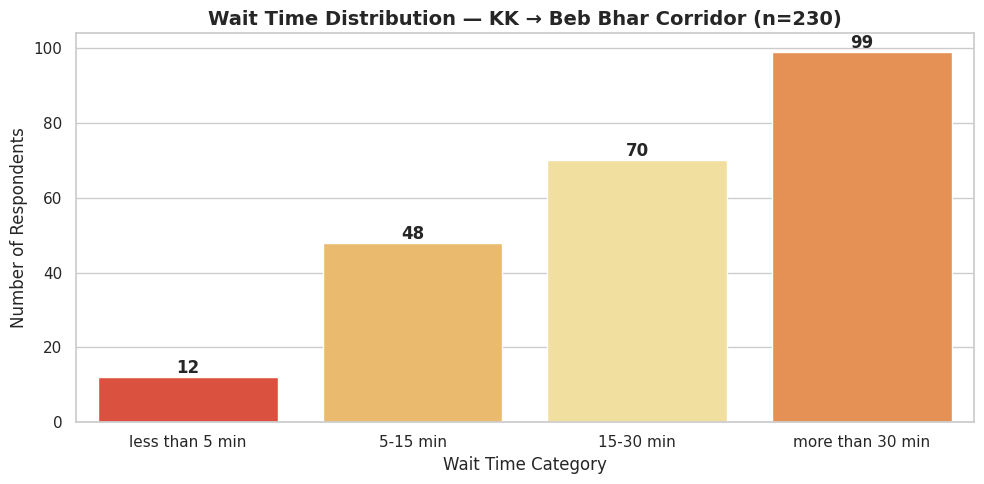

In [11]:

wait_order = ['less than 5 min', '5-15 min', '15-30 min', 'more than 30 min']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='wait_time', order=wait_order,
                   hue='wait_time', palette='YlOrRd', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Wait Time Distribution — KK → Beb Bhar Corridor (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Wait Time Category')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('chart1_wait_distribution.png', dpi=150)
plt.show()

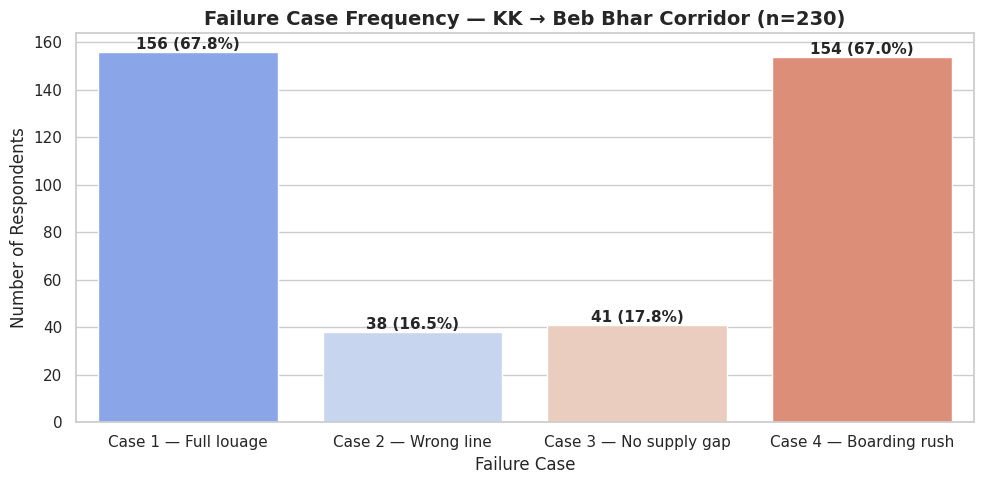

In [12]:

cases = pd.DataFrame({
    'Case': ['Case 1 — Full louage', 'Case 2 — Wrong line',
             'Case 3 — No supply gap', 'Case 4 — Boarding rush'],
    'Count': [df['case_full'].sum(), df['case_wrongline'].sum(),
              df['case_nogap'].sum(), df['case_rush'].sum()],
})
cases['Percentage'] = (cases['Count'] / 230 * 100).round(1)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cases, x='Case', y='Count',
                 hue='Case', palette='coolwarm', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({cases.loc[cases["Count"]==int(p.get_height()), "Percentage"].values[0]}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Failure Case Frequency — KK → Beb Bhar Corridor (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Failure Case')
plt.ylabel('Number of Respondents')
plt.xticks(wrap=True)
plt.tight_layout()
plt.savefig('chart2_failure_cases.png', dpi=150)
plt.show()

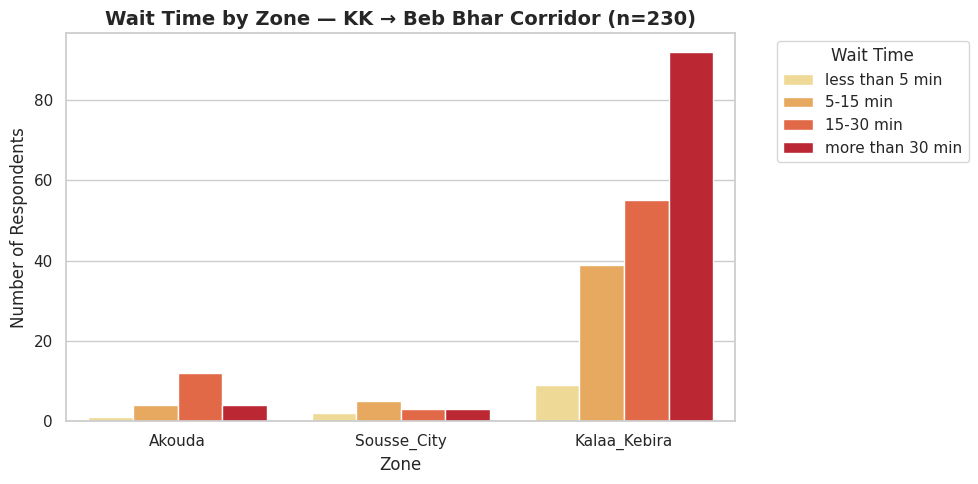

In [13]:
wait_order = ['less than 5 min', '5-15 min', '15-30 min', 'more than 30 min']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='zone', hue='wait_time',
                   hue_order=wait_order, palette='YlOrRd')

plt.title('Wait Time by Zone — KK → Beb Bhar Corridor (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Zone')
plt.ylabel('Number of Respondents')
plt.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart3_wait_by_zone.png', dpi=150)
plt.show()

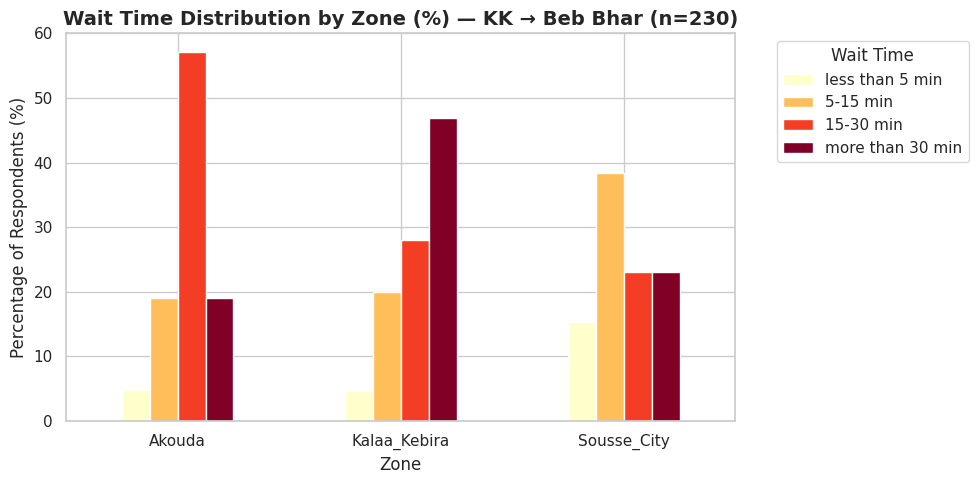

In [14]:

zone_wait = df.groupby(['zone', 'wait_time']).size().unstack(fill_value=0)
zone_wait_pct = zone_wait.div(zone_wait.sum(axis=1), axis=0) * 100
zone_wait_pct = zone_wait_pct[wait_order]

zone_wait_pct.plot(kind='bar', figsize=(10, 5),
                   colormap='YlOrRd', edgecolor='white')

plt.title('Wait Time Distribution by Zone (%) — KK → Beb Bhar (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Zone')
plt.ylabel('Percentage of Respondents (%)')
plt.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_wait_by_zone_pct.png', dpi=150)
plt.show()

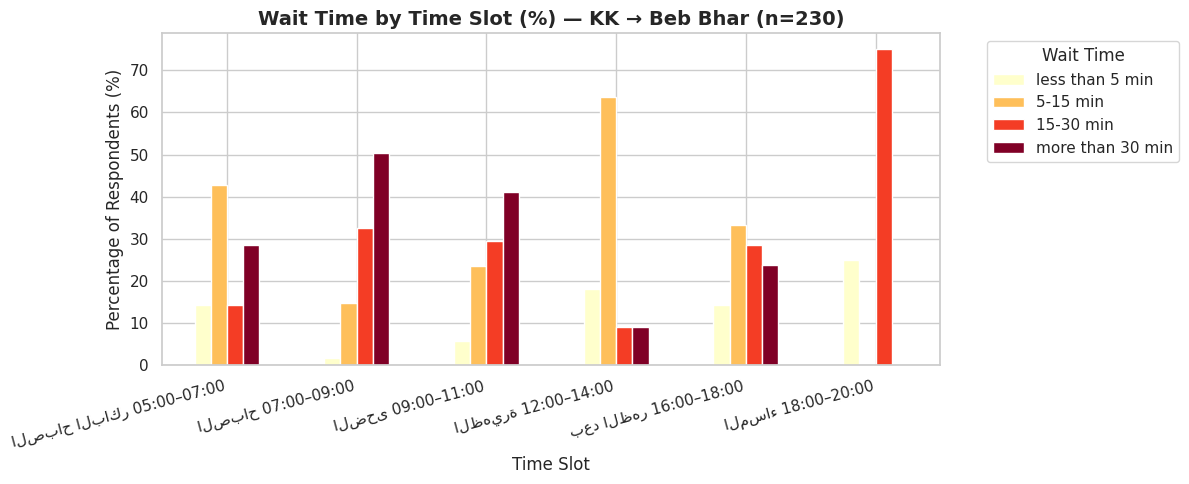

In [15]:
time_order = ['الصباح الباكر 05:00–07:00', 'الصباح 07:00–09:00',
              'الضحى 09:00–11:00', 'الظهيرة 12:00–14:00',
              'بعد الظهر 16:00–18:00', 'المساء 18:00–20:00']


time_wait = df.groupby(['time_slot', 'wait_time']).size().unstack(fill_value=0)
time_wait_pct = time_wait.div(time_wait.sum(axis=1), axis=0) * 100
time_wait_pct = time_wait_pct.reindex(time_order)[wait_order]

time_wait_pct.plot(kind='bar', figsize=(12, 5),
                   colormap='YlOrRd', edgecolor='white')

plt.title('Wait Time by Time Slot (%) — KK → Beb Bhar (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Time Slot')
plt.ylabel('Percentage of Respondents (%)')
plt.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('chart4_wait_by_timeslot.png', dpi=150)
plt.show()

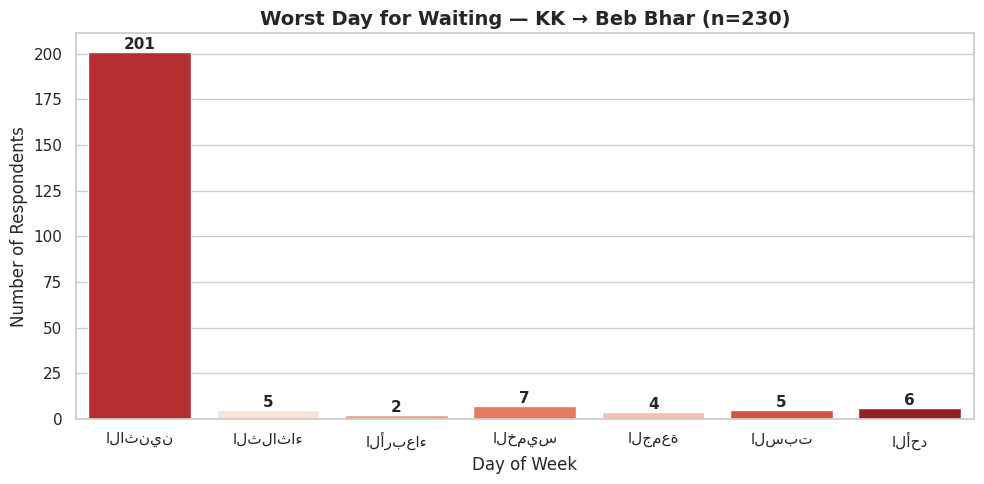

In [16]:
day_order = ['الاثنين', 'الثلاثاء', 'الأربعاء', 'الخميس',
             'الجمعة', 'السبت', 'الأحد']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='worst_day', order=day_order,
                   hue='worst_day', palette='Reds_r', legend=False)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Worst Day for Waiting — KK → Beb Bhar (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('chart5_worst_day.png', dpi=150)
plt.show()

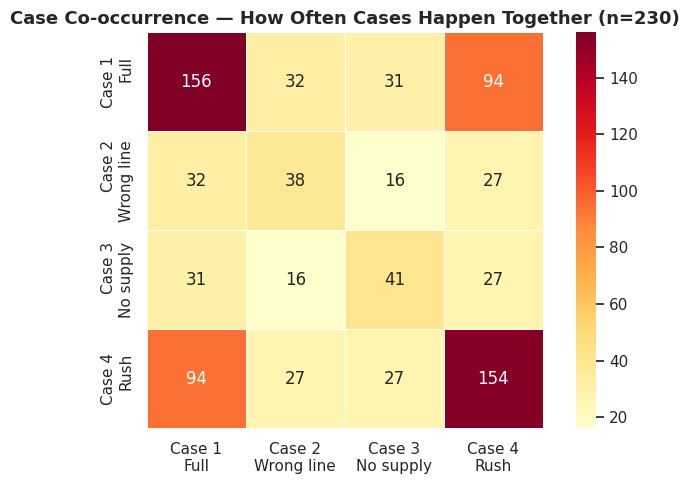

In [17]:
cases_df = df[['case_full', 'case_wrongline', 'case_nogap', 'case_rush']]
cases_df.columns = ['Case 1\nFull', 'Case 2\nWrong line',
                    'Case 3\nNo supply', 'Case 4\nRush']

co_occurrence = cases_df.T.dot(cases_df)

plt.figure(figsize=(7, 5))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, square=True)

plt.title('Case Co-occurrence — How Often Cases Happen Together (n=230)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_case_cooccurrence.png', dpi=150)
plt.show()

##  Feature Engineering & Encoding
*Prepare X and y for modelling*

##  Model Training & Evaluation
*Decision Tree, Random Forest, XGBoost*

## 7. Model Explainability (SHAP)